# Project 3: Classification__

### __Objective__
In this lab, you will apply supervised learning (classification) models to predict one of the following
1. **Loan Approval Outcomes** : The dataset includes demographic, financial, and credit history features of loan applicants.
2. **Airline Passenger Satisfaction** : Customer satisfaction scores from 120,000+ airline passengers, including additional information about each passenger, their flight, and type of travel, as well as ther evaluation of different factors like cleanliness, comfort, service, and overall experience.
3. **Hotel Booking Cancellations** : booking information for a city hotel and a resort hotel, and includes information such as when the booking was made, length of stay, the number of adults, children, and/or babies, and the number of available parking spaces, among other things

### __Requirements__
Your task is to explore the data, clean and preprocess it appropriately, and build predictive models. Specifically, you must:
1. **Perform EDA**: Explore distributions, identify missing values, and check for class imbalance in the target variable.
2. **Preprocess the Data**: Handle categorical encodings, impute missing values, and scale your features. *Hint: Make sure to perform your train-test split BEFORE scaling to prevent data leakage!*
3. **Train Classification Models**: train **two** classification models (**Logistic Regression** and **KNN**).
5. **Evaluate & Compare**: Evaluate models using accuracy, precision, recall, F1-score, and confusion matrices. 

### __Deliverables__
You are expected to document your workflow using Markdown cells. Do not just write code; explain your **rationale**. Include insights from your EDA, justify your preprocessing decisions, and conclude with a comparative analysis discussing which of the three models performed best and why.

---

## __Data Dictionary__

___Copy you assigned dataset's dictionary from the guidleines___

---

## Setup and Data Loading
Import your libraries and load the dataset.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

# Add your sklearn imports here...
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline 

In [2]:
# Load the dataset
# df = pd.read_csv('...')
df = pd.read_csv('./data/airline_passenger_satisfaction.csv',index_col=0)

# df.head()
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,male,48,First-time,business,Business,821 miles,2 minutes,5.0 minutes,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,FEMALE,35,returning,Business,Business,821 miles,26 minutes,39.0 minutes,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853 miles,0 minutes,0.0 minutes,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,business,Business,1905 miles,0 minutes,0.0 minutes,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,returning,business,Business,3470 miles,0 minutes,1.0 minutes,3,...,3,4,4,5,4,3,3,3,3,Satisfied


## Part 1: Exploratory Data Analysis (EDA)
* What insights did you gain from your EDA? Are there missing values? Outliers? Is the target variable balanced or imbalanced? Use visualizations to support your findings.

In [3]:
# Your EDA code here 
# Note: you are not required to answer in this single cell, create more cells if needed
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 136374 entries, 0 to 136373
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   ID                                      136374 non-null  int64
 1   Gender                                  136374 non-null  str  
 2   Age                                     136374 non-null  int64
 3   Customer Type                           136374 non-null  str  
 4   Type of Travel                          136374 non-null  str  
 5   Class                                   136374 non-null  str  
 6   Flight Distance                         136374 non-null  str  
 7   Departure Delay                         136374 non-null  str  
 8   Arrival Delay                           136374 non-null  str  
 9   Departure and Arrival Time Convenience  136374 non-null  int64
 10  Ease of Online Booking                  136374 non-null  int64
 11  Check-in Se

In [4]:
df.isnull().sum()

ID                                        0
Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment                   0
Baggage Handling                

In [5]:
df['Gender'].value_counts()

Gender
Female    48470
Male      46992
FEMALE    20773
male      20139
Name: count, dtype: int64

In [6]:
#Problem 1: Typeing Error in 'Gender' column
df['Gender'] = df['Gender'].replace('FEMALE','Female' )
df['Gender'] = df['Gender'].replace('male','Male' )
df['Gender'].value_counts()

Gender
Female    69243
Male      67131
Name: count, dtype: int64

In [7]:
df['Customer Type'].value_counts()

Customer Type
Returning       77949
returning       33407
First-time      17513
 First-time      7505
Name: count, dtype: int64

In [8]:
#Problem 2: Typeing Error in 'Customer Type' column
df['Customer Type'] = df['Customer Type'].replace('returning', 'Returning')
df['Customer Type'] = df['Customer Type'].str.strip()
df['Customer Type'].value_counts()

Customer Type
Returning     111356
First-time     25018
Name: count, dtype: int64

In [9]:
df['Type of Travel'].value_counts()

Type of Travel
Business    65875
Personal    29587
business    28232
PERSONAL    12680
Name: count, dtype: int64

In [10]:
#Problem 3: Typeing Error in 'Type of Travel' column
df['Type of Travel'] = df['Type of Travel'].replace('business', 'Business')
df['Type of Travel'] = df['Type of Travel'].replace('PERSONAL', 'Personal')
df['Type of Travel'].value_counts()

Type of Travel
Business    94107
Personal    42267
Name: count, dtype: int64

In [11]:
df['Class'].value_counts()

Class
Business        45674
Economy         42893
 Business       19574
ECONOMY         18382
Economy Plus     6896
ECONOMY PLUS     2955
Name: count, dtype: int64

In [12]:
#Problem 4: Typeing Error in 'Class' column
df['Class'] = df['Class'].str.strip()
df['Class'] = df['Class'].replace('ECONOMY', 'Economy')
df['Class'] = df['Class'].replace('ECONOMY PLUS', 'Economy Plus')
df['Class'].value_counts()

Class
Business        65248
Economy         61275
Economy Plus     9851
Name: count, dtype: int64

In [13]:
#Problem 5: 'Flight Distance' column is string
df['Flight Distance'] = df['Flight Distance'].str.extract(r'(\d+)').astype(int)
df['Flight Distance']

0          821
1          821
2          853
3         1905
4         3470
          ... 
136369    1448
136370    3384
136371     373
136372    1583
136373    1011
Name: Flight Distance, Length: 136374, dtype: int64

In [14]:
df['Departure Delay']

0          2 minutes
1         26 minutes
2          0 minutes
3          0 minutes
4          0 minutes
             ...    
136369     7 minutes
136370     0 minutes
136371     0 minutes
136372     0 minutes
136373    67 minutes
Name: Departure Delay, Length: 136374, dtype: str

In [15]:
#Problem 5: 'Departure Delay' column is string
df['Departure Delay'] = (df['Departure Delay'].str.extract(r'(\d+)')[0].astype(int))
df['Departure Delay']

0          2
1         26
2          0
3          0
4          0
          ..
136369     7
136370     0
136371     0
136372     0
136373    67
Name: Departure Delay, Length: 136374, dtype: int64

In [16]:
df['Arrival Delay'].str.split().str[-1].value_counts()


Arrival Delay
minutes    136374
Name: count, dtype: int64

In [17]:
df['Arrival Delay'].isnull().sum()

np.int64(0)

In [18]:
#Problem 6: 'Arrival Delay' column is string
df['Arrival Delay'] = df['Arrival Delay'].str.extract(r'(\d+)')[0]
df['Arrival Delay']

0          5
1         39
2          0
3          0
4          1
          ..
136369    32
136370     0
136371     0
136372     0
136373    63
Name: Arrival Delay, Length: 136374, dtype: str

In [19]:
#Problem 6 Solution: Dropping the nulls
df.loc[df['Arrival Delay'].str.extract(r'(\d+)')[0].isna(), 'Arrival Delay']

246       NaN
883       NaN
1965      NaN
2407      NaN
2448      NaN
         ... 
135497    NaN
135637    NaN
135919    NaN
136144    NaN
136209    NaN
Name: Arrival Delay, Length: 415, dtype: str

In [20]:
df.dropna(subset=['Arrival Delay'],inplace=True)

In [21]:
df['Arrival Delay'].astype(int)

0          5
1         39
2          0
3          0
4          1
          ..
136369    32
136370     0
136371     0
136372     0
136373    63
Name: Arrival Delay, Length: 135959, dtype: int64

In [22]:
df['Arrival Delay'] = pd.to_numeric(df['Arrival Delay'], errors='coerce')
df['Arrival Delay'].dtypes

dtype('int64')

In [23]:
df['Departure and Arrival Time Convenience'].value_counts()

Departure and Arrival Time Convenience
4    33416
5    29317
3    23406
2    22547
1    20290
0     6983
Name: count, dtype: int64

In [24]:
#Problem 7: 5988 value equal to 0 in 'Ease of Online Booking' column
df['Ease of Online Booking'].value_counts()

Ease of Online Booking
3    31775
2    31509
4    25611
1    22861
5    18232
0     5971
Name: count, dtype: int64

In [25]:
#Problem 8: 1 value equal to 0 in 'Check-in Service' column
df['Check-in Service'].value_counts()

Check-in Service
4    37997
3    37167
5    27076
1    16861
2    16857
0        1
Name: count, dtype: int64

In [26]:
#Problem 9: 3259 values equal to 0 in 'Online Boarding' column
df['Online Boarding'].value_counts()

Online Boarding
4    40193
3    28401
5    27249
2    22963
1    13904
0     3249
Name: count, dtype: int64

In [27]:
#Problem 10: 1 value equal to 0 in 'Gate Location' column
df['Gate Location'].value_counts()

Gate Location
3    37440
4    31928
2    25377
1    23004
5    18209
0        1
Name: count, dtype: int64

In [28]:
#Problem 11: 1 value equal to 0 in 'On-board Service' column
df['On-board Service'].value_counts()

On-board Service
4    40484
5    30848
3    29927
2    19214
1    15481
0        5
Name: count, dtype: int64

In [29]:
#Problem 12: 1 value equal to 0 in 'Seat Comfort' column
df['Seat Comfort'].value_counts()

Seat Comfort
4    41605
5    34726
3    24400
2    19402
1    15825
0        1
Name: count, dtype: int64

In [30]:
#Problem 13: 629 values equal to 0 in 'Leg Room Service' column
df['Leg Room Service'].value_counts()

Leg Room Service
4    37616
5    32352
3    26239
2    25675
1    13450
0      627
Name: count, dtype: int64

In [31]:
#Problem 14: 14 values equal to 0 in 'Cleanliness' column
df['Cleanliness'].value_counts()

Cleanliness
4    35509
3    32112
5    29786
2    21056
1    17482
0       14
Name: count, dtype: int64

In [32]:
#Problem 15: 140 values equal to 0 in 'Food and Drink' column
df['Food and Drink'].value_counts()

Food and Drink
4    31982
5    29273
3    29108
2    28655
1    16803
0      138
Name: count, dtype: int64

In [33]:
#Problem 16: 5 values equal to 0 in 'In-flight Service' column
df['In-flight Service'].value_counts()

In-flight Service
4    49583
5    35613
3    26511
2    14983
1     9264
0        5
Name: count, dtype: int64

In [34]:
#Problem 17: 4105 values equal to 0 in 'In-flight Wifi Service' column
df['In-flight Wifi Service'].value_counts()

In-flight Wifi Service
2    33873
3    33666
4    25914
1    23382
5    15027
0     4097
Name: count, dtype: int64

In [35]:
#Problem 18: 18 values equal to 0 in 'In-flight Entertainment' column
df['In-flight Entertainment'].value_counts()

In-flight Entertainment
4    38502
5    33042
3    25022
2    22991
1    16384
0       18
Name: count, dtype: int64

In [36]:
df['Baggage Handling'].value_counts()

Baggage Handling
4    48973
5    35465
3    27075
2    15016
1     9430
Name: count, dtype: int64

In [37]:
df['Satisfaction'].value_counts()

Satisfaction
Neutral or Dissatisfied    76923
Satisfied                  59036
Name: count, dtype: int64

In [38]:
df.info()

<class 'pandas.DataFrame'>
Index: 135959 entries, 0 to 136373
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   ID                                      135959 non-null  int64
 1   Gender                                  135959 non-null  str  
 2   Age                                     135959 non-null  int64
 3   Customer Type                           135959 non-null  str  
 4   Type of Travel                          135959 non-null  str  
 5   Class                                   135959 non-null  str  
 6   Flight Distance                         135959 non-null  int64
 7   Departure Delay                         135959 non-null  int64
 8   Arrival Delay                           135959 non-null  int64
 9   Departure and Arrival Time Convenience  135959 non-null  int64
 10  Ease of Online Booking                  135959 non-null  int64
 11  Check-in Service

In [39]:
df.columns = df.columns.str.strip()

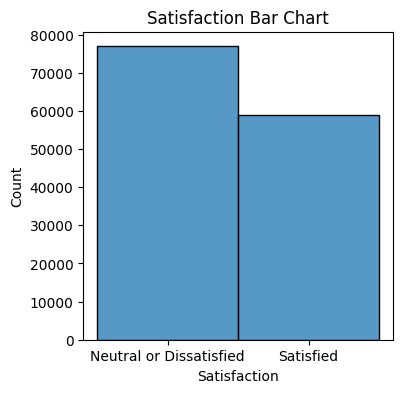

In [40]:
plt.figure(figsize=(4,4))
sns.histplot(df['Satisfaction'])
plt.title('Satisfaction Bar Chart')
plt.show()

,variable,staistic,pvalue,dof
0,Gender,15.991845,0.000064,1
1,Customer Type,4681.783635,0.000000,1
2,Type of Travel,27573.027960,0.000000,1
3,Class,34495.263974,0.000000,2


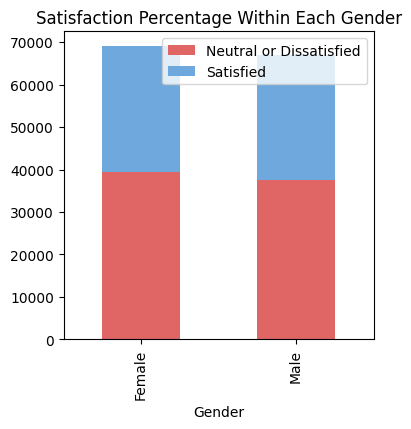

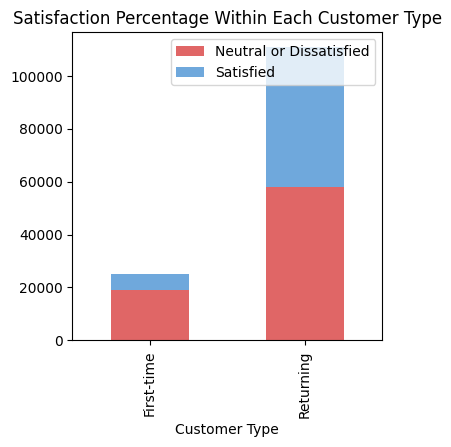

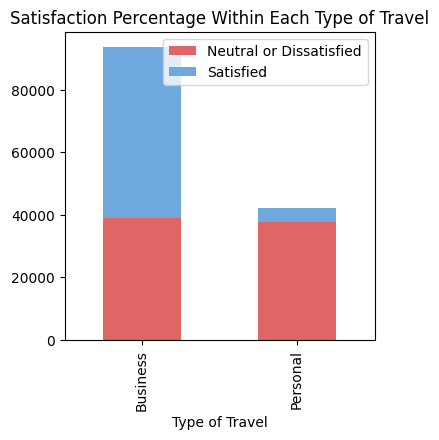

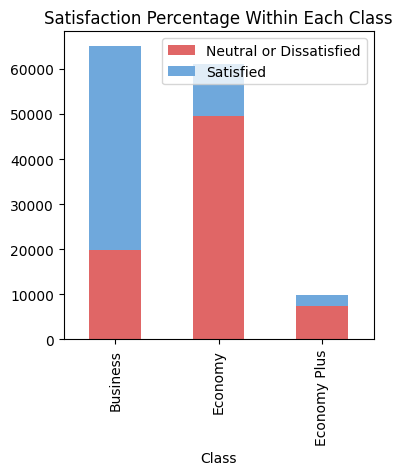

In [72]:
#Relationship between Categorial Features and Target
categoricl_columns = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
results_list = []
for col in categoricl_columns:
    contingency_table = pd.crosstab(df[col], df['Satisfaction'])
    contingency_table.plot(kind='bar',stacked=True, figsize=(4,4), color=['#e06666', '#6fa8dc'])
    plt.title(f'Satisfaction Percentage Within Each {col}')
    plt.legend(loc='upper right')
    results = chi2_contingency(contingency_table)
    results_list.append({
        'variable': col,
        'staistic':results.statistic,
        'pvalue': results.pvalue,
        'dof': results.dof
    })
results_df = pd.DataFrame(results_list)
display(results_df)


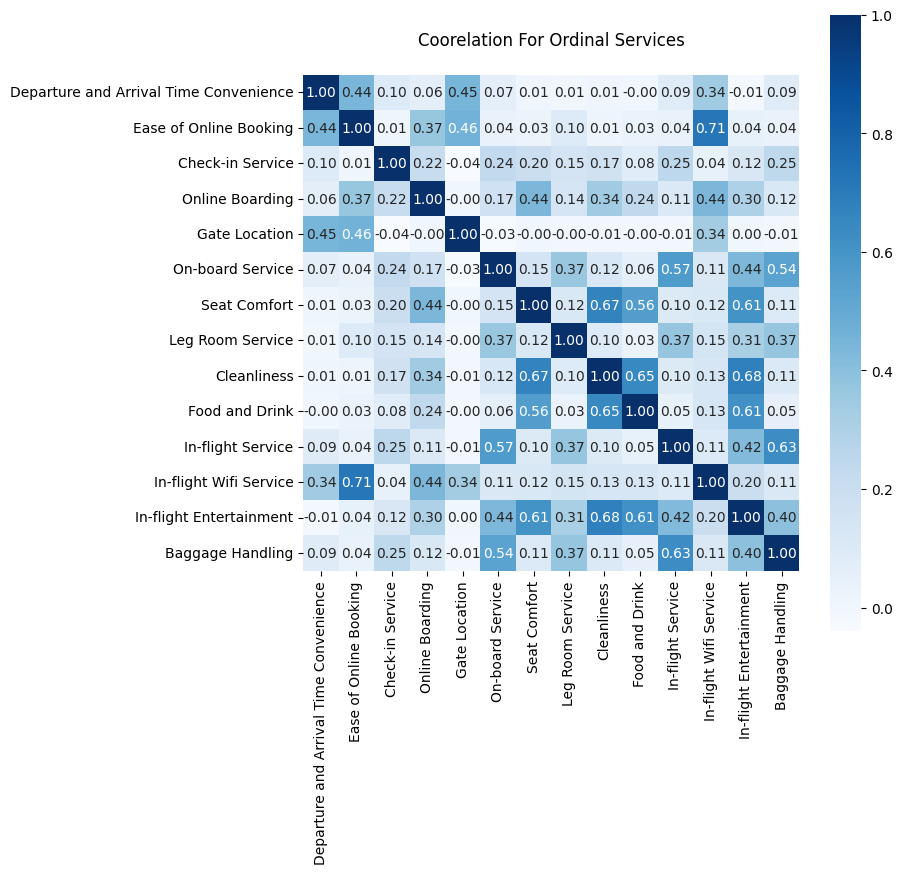

In [73]:
#Correlation between Ordinal Features
ordinarily_columns = ['Departure and Arrival Time Convenience','Ease of Online Booking',
                      'Check-in Service','Online Boarding','Gate Location','On-board Service',
                      'Seat Comfort','Leg Room Service','Cleanliness','Food and Drink','In-flight Service',
                      'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling'
]
ordinarily_correlation = df[ordinarily_columns].corr(method='spearman')

plt.figure(figsize=(8,8))
sns.heatmap(ordinarily_correlation, annot=True,fmt='.2f',cmap='Blues',square=True)
plt.title('Spearman Coorelation of Ordinal Features\n')
plt.show()

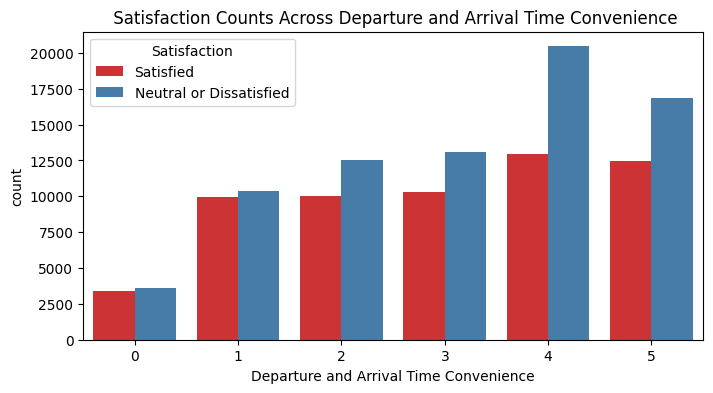

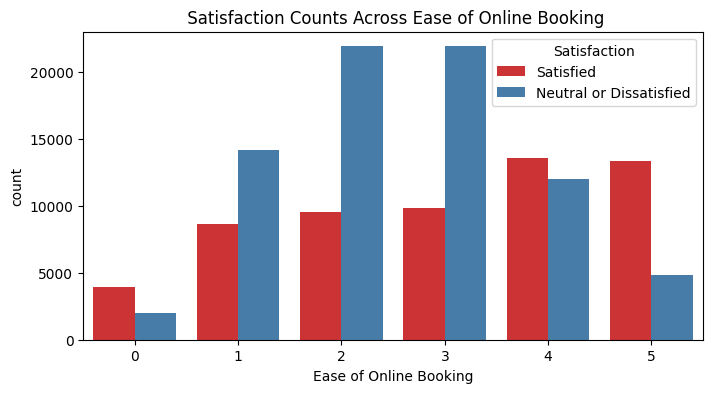

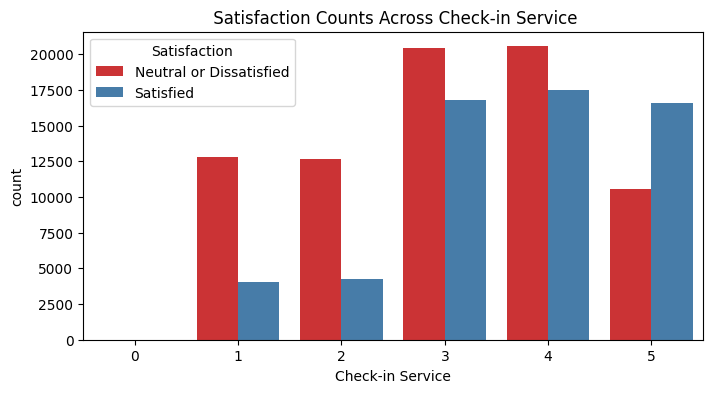

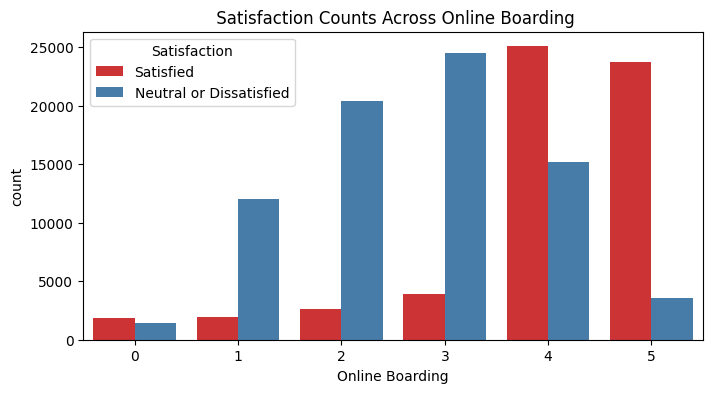

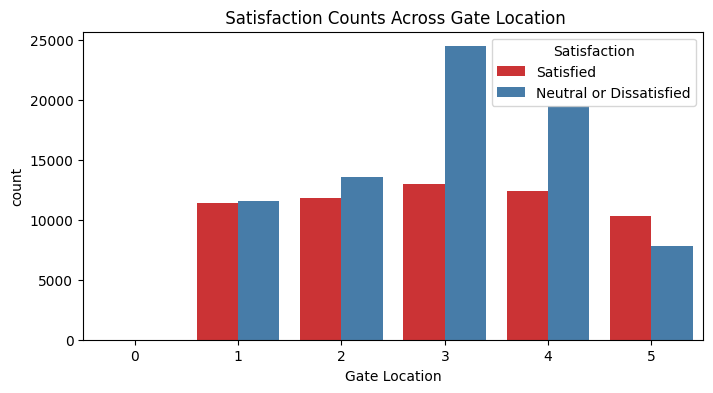

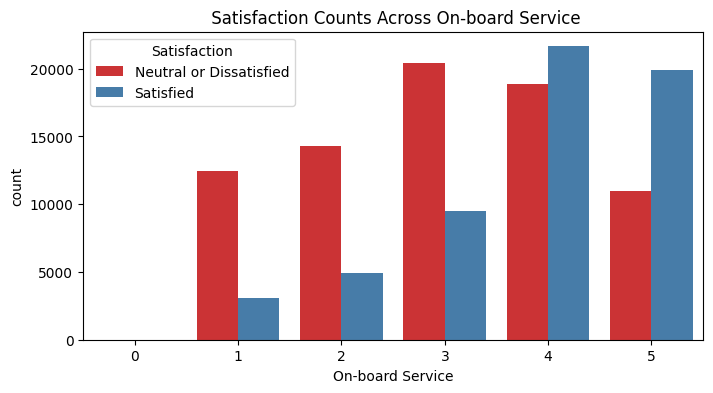

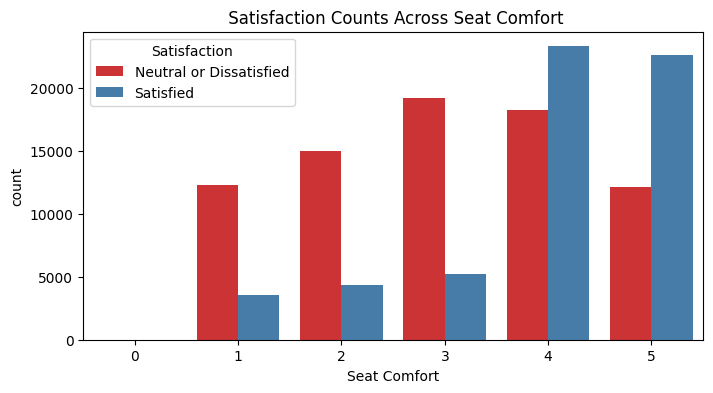

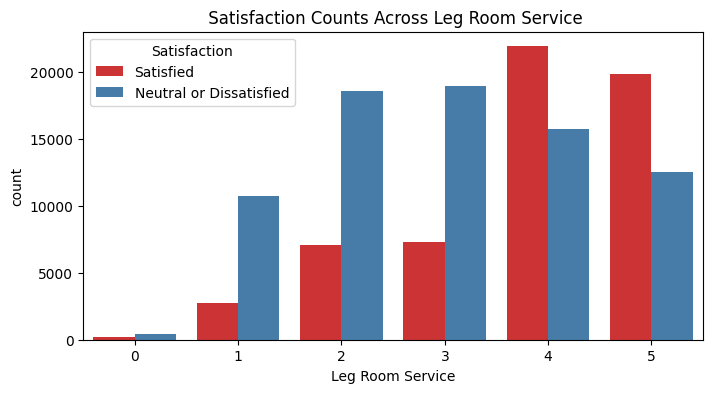

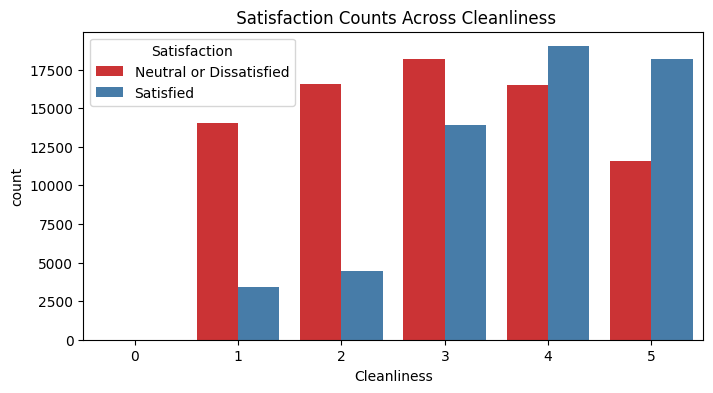

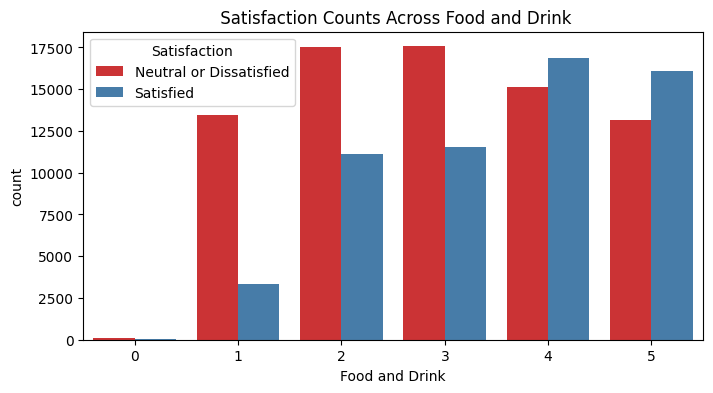

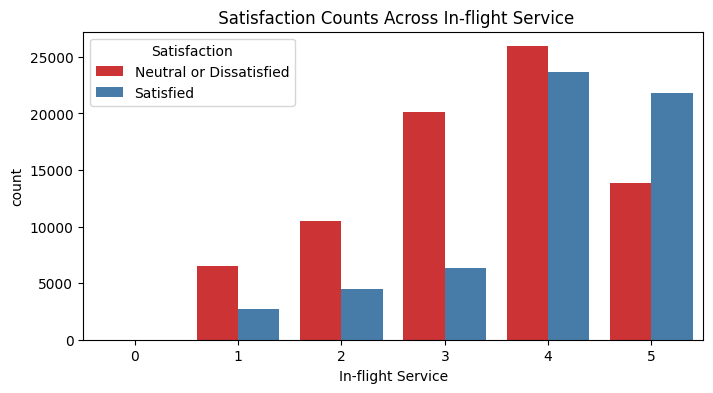

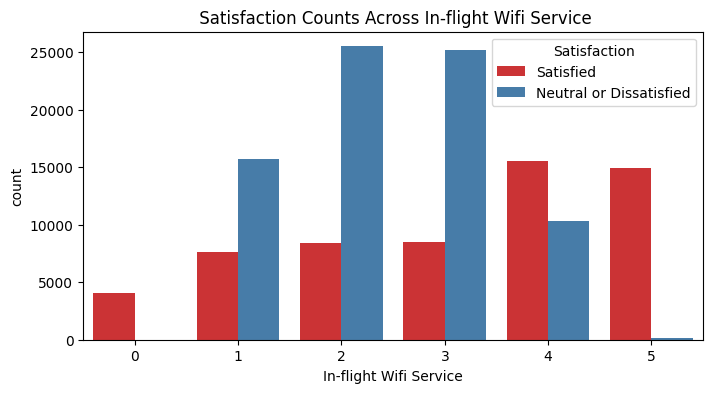

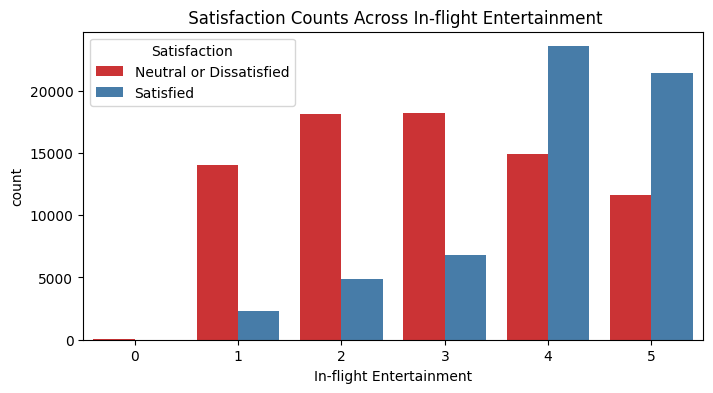

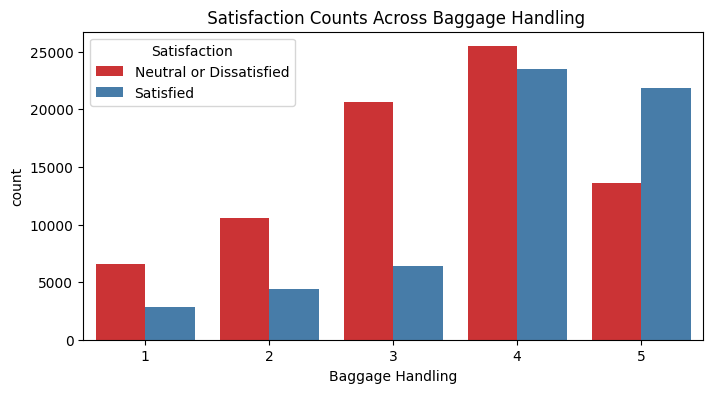

In [43]:
for col in ordinarily_columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='Satisfaction', data=df, palette='Set1')
    plt.title(f' Satisfaction Counts Across {col}')
    plt.show()

In [44]:
df['Satisfaction'].value_counts()

Satisfaction
Neutral or Dissatisfied    76923
Satisfied                  59036
Name: count, dtype: int64

In [45]:
#Convert 'Satisfaction' column into 0 and 1
df['numeric_Satisfaction'] = df['Satisfaction'].map({'Satisfied':1,'Neutral or Dissatisfied':0})
df['numeric_Satisfaction'].value_counts()

numeric_Satisfaction
0    76923
1    59036
Name: count, dtype: int64

In [46]:
#Calculate the Correlation between ordinarly features and target
target_ordinarily_correlation = df[ordinarily_columns].corrwith(df['numeric_Satisfaction'], method='spearman')
target_ordinarily_correlation

Departure and Arrival Time Convenience   -0.052569
Ease of Online Booking                    0.174660
Check-in Service                          0.233267
Online Boarding                           0.549893
Gate Location                            -0.003754
On-board Service                          0.327472
Seat Comfort                              0.361239
Leg Room Service                          0.316936
Cleanliness                               0.304475
Food and Drink                            0.208705
In-flight Service                         0.265437
In-flight Wifi Service                    0.286899
In-flight Entertainment                   0.398913
Baggage Handling                          0.270044
dtype: float64

In [47]:
target_ordinarily_correlation_df = target_ordinarily_correlation.reset_index()
target_ordinarily_correlation_df.columns = ['Services', 'Correlation with Satisfaction']
target_ordinarily_correlation_df = target_ordinarily_correlation_df.sort_values(by='Correlation with Satisfaction', ascending=False)
target_ordinarily_correlation_df

,Services,Correlation with Satisfaction
3,Online Boarding,0.549893
12,In-flight Entertainment,0.398913
6,Seat Comfort,0.361239
5,On-board Service,0.327472
7,Leg Room Service,0.316936
8,Cleanliness,0.304475
11,In-flight Wifi Service,0.286899
13,Baggage Handling,0.270044
10,In-flight Service,0.265437
2,Check-in Service,0.233267


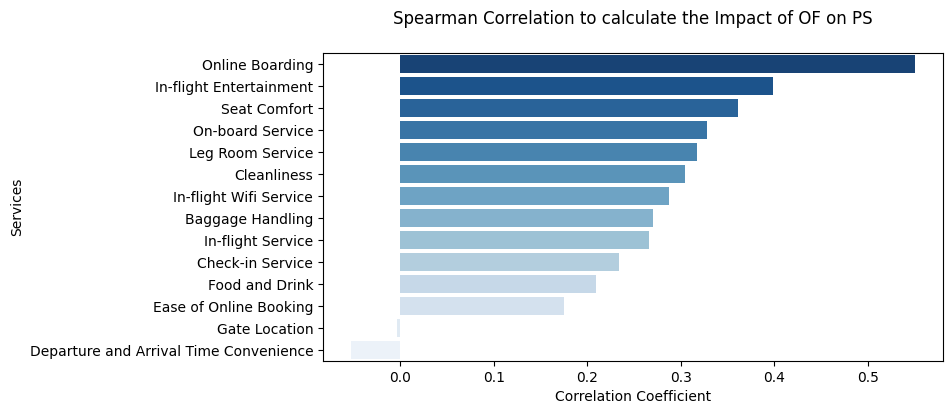

In [74]:
plt.figure(figsize=(8,4))
sns.barplot(
    x='Correlation with Satisfaction',
    y='Services', 
    data=target_ordinarily_correlation_df,
    palette='Blues_r',
    hue='Services',
    legend=False
)
plt.title('Spearman Correlation to calculate the Impact of OF on PS\n')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Services')
plt.show()

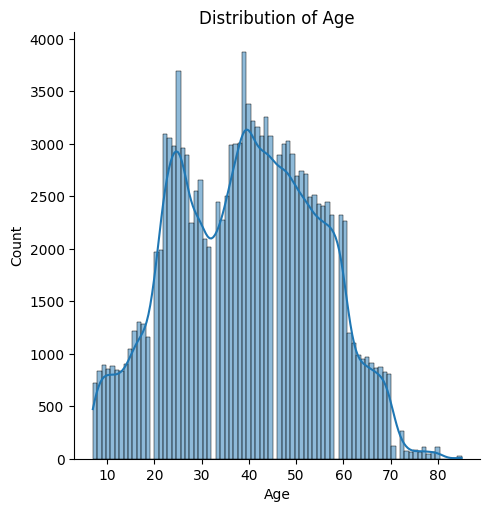

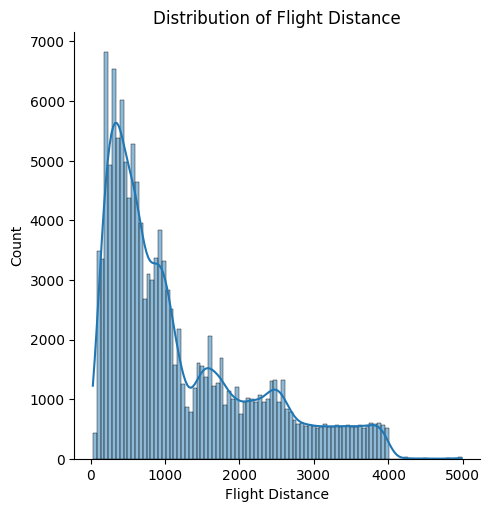

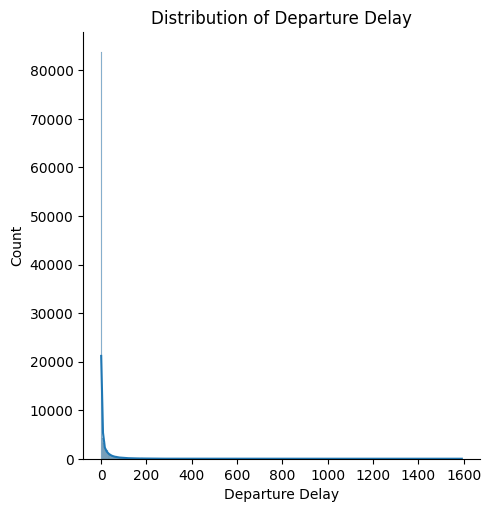

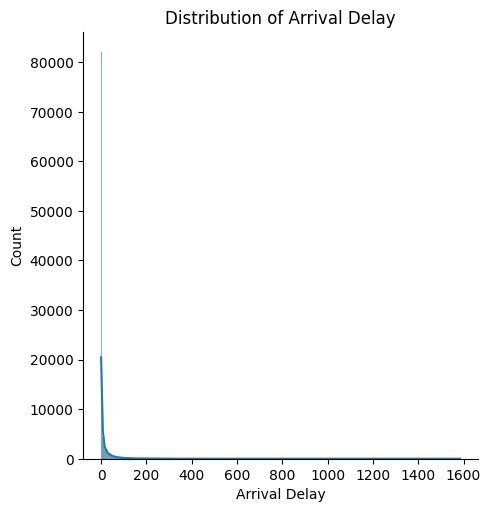

In [49]:
continuous_col = ['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay']
for col in continuous_col:
    sns.displot(df[col],kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [ ]:
pearson_corr = df[['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']].corr()

# رسم الخريطة الحرارية لبيرسون
plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Pearson Correlation Matrix (Linear Relationship)')
plt.show()

# طباعة الرقم المحدد بين التأخيرات
print(f"الارتباط الخطي (Pearson) بين تأخير المغادرة والوصول هو: {pearson_corr.iloc[2,3]:.2f}")

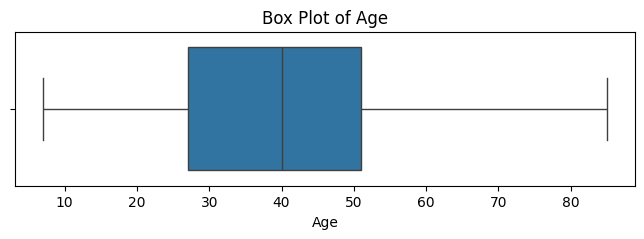

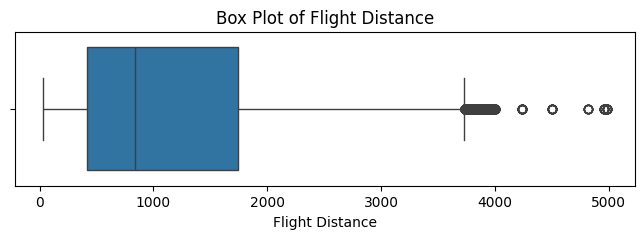

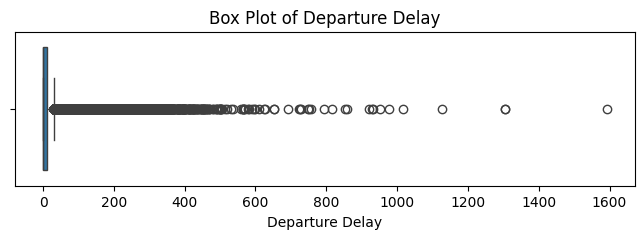

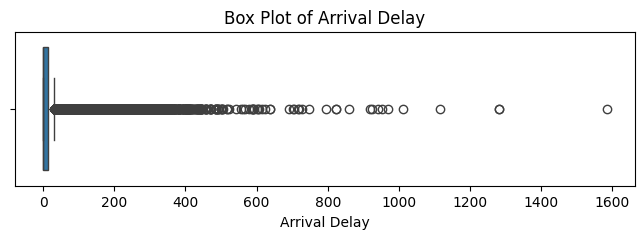

In [50]:
for col in continuous_col:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

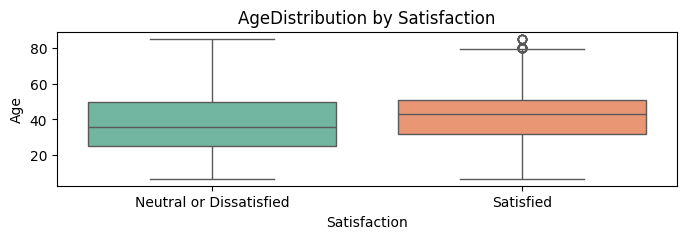

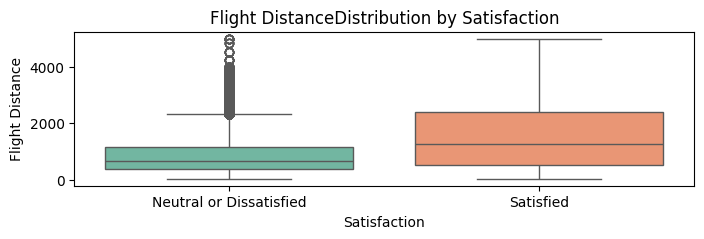

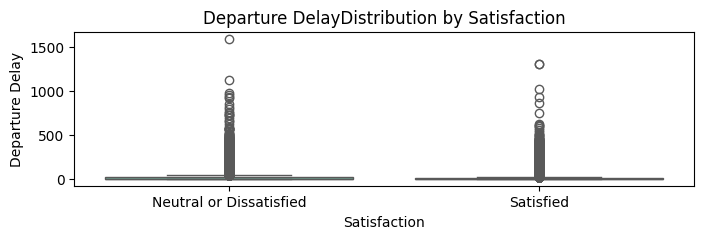

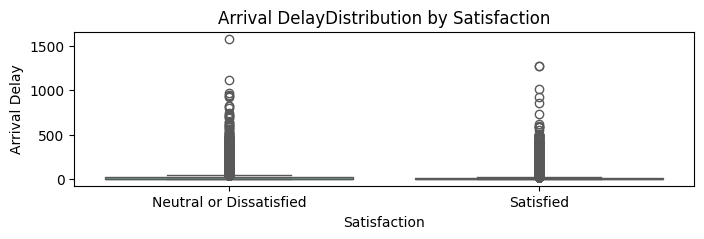

In [51]:
for col in continuous_col:
    plt.figure(figsize=(8,2))
    sns.boxplot(x='Satisfaction', y=col, data=df, palette='Set2', hue='Satisfaction', legend=False)
    plt.title(f'{col}Distribution by Satisfaction')
    plt.show()

In [52]:
#Continuous variables and Target

satisfied = df[df['numeric_Satisfaction'] == 1]
dissatisfied = df[df['numeric_Satisfaction'] == 0]

results2_list = []
for col in continuous_col:
    mean_satisfied = df[df['numeric_Satisfaction'] == 1][col].mean()
    mean_dissatisfied = df[df['numeric_Satisfaction'] == 0][col].mean()
    results2 = mannwhitneyu(satisfied[col], dissatisfied[col])
    results2_list.append({
        'Variable': col,
        'Statistic': results2.statistic,
        'P_value': results2.pvalue,
        'Mean Satisfied': mean_satisfied,
        'Mean Dissatisfied': mean_dissatisfied
    })
results2_df = pd.DataFrame(results2_list)
results2_df

,Variable,Statistic,P_value,Mean Satisfied,Mean Dissatisfied
0,Age,2.651613e+09,0.000000e+00,41.734603,37.637287
1,Flight Distance,2.948676e+09,0.000000e+00,1527.972356,927.921792
2,Departure Delay,2.106333e+09,2.976304e-141,12.464835,16.343395
3,Arrival Delay,2.028439e+09,2.472235e-303,12.554729,17.061659


                      Age  Flight Distance  Departure Delay  Arrival Delay
Age              1.000000         0.072828        -0.008558      -0.009756
Flight Distance  0.072828         1.000000         0.026627      -0.001306
Departure Delay -0.008558         0.026627         1.000000       0.740161
Arrival Delay   -0.009756        -0.001306         0.740161       1.000000


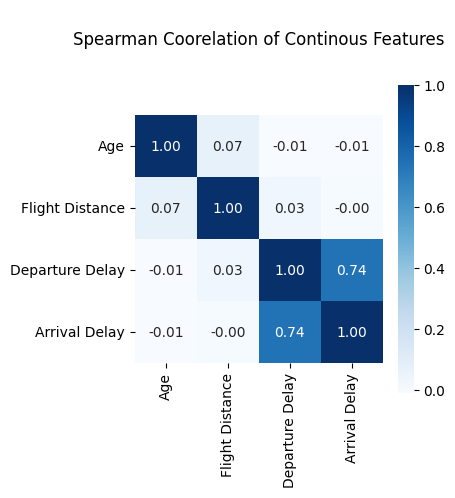

In [78]:
#ٌRelation between Continous varaibles using spearman
continuous_correlation = df[continuous_col].corr(method='spearman')
print(continuous_correlation)
plt.figure(figsize=(4,4))
sns.heatmap(continuous_correlation, annot=True,fmt='.2f',cmap='Blues',square=True)
plt.title('\nSpearman Coorelation of Continous Features\n\n\n')
plt.show()

## Part 2: Data Preprocessing
* Explain your strategy for handling categorical variables (e.g., One-Hot Encoding vs Label Encoding) and missing data.  
**Crucial:** Remember to split your data into training and testing sets BEFORE applying scaling to prevent data leakage.

In [54]:
columns_to_drop = ['ID', 'Gender', 'Satisfaction', 'Gate Location']
df_cleaned = df.drop(columns= columns_to_drop, errors='ignore')
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 135959 entries, 0 to 136373
Data columns (total 21 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   Age                                     135959 non-null  int64
 1   Customer Type                           135959 non-null  str  
 2   Type of Travel                          135959 non-null  str  
 3   Class                                   135959 non-null  str  
 4   Flight Distance                         135959 non-null  int64
 5   Departure Delay                         135959 non-null  int64
 6   Arrival Delay                           135959 non-null  int64
 7   Departure and Arrival Time Convenience  135959 non-null  int64
 8   Ease of Online Booking                  135959 non-null  int64
 9   Check-in Service                        135959 non-null  int64
 10  Online Boarding                         135959 non-null  int64
 11  On-board Service

In [55]:
type(df_cleaned)

pandas.DataFrame

In [56]:
df_cleaned['Type of Travel'].value_counts()

Type of Travel
Business    93847
Personal    42112
Name: count, dtype: int64

In [57]:
df_cleaned['Customer_Type_Numeric'] = df_cleaned['Customer Type'].map({'Returning': 1, 'First-time': 0})
df_cleaned['Type_of_Travel_Numeric'] = df_cleaned['Type of Travel'].map({'Business': 1, 'Personal': 0})
df_cleaned = df_cleaned.drop(columns=['Customer Type', 'Type of Travel'])
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 135959 entries, 0 to 136373
Data columns (total 21 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   Age                                     135959 non-null  int64
 1   Class                                   135959 non-null  str  
 2   Flight Distance                         135959 non-null  int64
 3   Departure Delay                         135959 non-null  int64
 4   Arrival Delay                           135959 non-null  int64
 5   Departure and Arrival Time Convenience  135959 non-null  int64
 6   Ease of Online Booking                  135959 non-null  int64
 7   Check-in Service                        135959 non-null  int64
 8   Online Boarding                         135959 non-null  int64
 9   On-board Service                        135959 non-null  int64
 10  Seat Comfort                            135959 non-null  int64
 11  Leg Room Service

In [58]:
df['Class'].value_counts()

Class
Business        65070
Economy         61072
Economy Plus     9817
Name: count, dtype: int64

In [59]:
df_cleaned['Class_Business'] = (df_cleaned['Class'] == 'Business').astype(int)
df_cleaned['Class_Economy'] = (df_cleaned['Class'] == 'Economy').astype(int)
df_cleaned['Class_Economy_Plus'] = (df_cleaned['Class'] == 'Economy Plus').astype(int)
df_cleaned = df_cleaned.drop(columns=['Class'])
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 135959 entries, 0 to 136373
Data columns (total 23 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   Age                                     135959 non-null  int64
 1   Flight Distance                         135959 non-null  int64
 2   Departure Delay                         135959 non-null  int64
 3   Arrival Delay                           135959 non-null  int64
 4   Departure and Arrival Time Convenience  135959 non-null  int64
 5   Ease of Online Booking                  135959 non-null  int64
 6   Check-in Service                        135959 non-null  int64
 7   Online Boarding                         135959 non-null  int64
 8   On-board Service                        135959 non-null  int64
 9   Seat Comfort                            135959 non-null  int64
 10  Leg Room Service                        135959 non-null  int64
 11  Cleanliness     

In [60]:
# Your preprocessing, train_test_split, and scaling code here
X= df_cleaned.drop(columns=['numeric_Satisfaction'])
y= df_cleaned['numeric_Satisfaction']
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, stratify=y)
# Note: you are not required to answer in this single cell, create more cells if needed


In [62]:
base_log_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),                      
    ('smote', SMOTE(random_state=42)),               
    ('classifier', LogisticRegression(solver='saga' , max_iter=10000, random_state=42)) 
])

base_log_pipeline.fit(X_train, y_train)
print(classification_report(y_test, base_log_pipeline.predict(X_test),target_names=['Neutral or Dissatisfied', 'Satisfied']))


                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.89      0.88      0.88     15385
              Satisfied       0.84      0.85      0.85     11807

               accuracy                           0.87     27192
              macro avg       0.86      0.86      0.86     27192
           weighted avg       0.87      0.87      0.87     27192



In [64]:
log_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),                      
    ('smote', SMOTE(random_state=42)),               
    ('classifier', LogisticRegression(solver='saga' , max_iter=10000, random_state=42)) 
])

log_param_grid = {
    'classifier__penalty':['elasticnet'],
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__l1_ratio': [0.2, 0.5, 0.8]
}

log_grid_search = GridSearchCV(log_pipeline, log_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
log_grid_search.fit(X_train, y_train)



C:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__l1_ratio': [0.2, 0.5, ...], 'classifier__penalty': ['elasticnet']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [65]:
base_knn_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scalar', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
])

base_knn_pipeline.fit(X_train, y_train)
print(classification_report(y_test, base_knn_pipeline.predict(X_test),target_names=['Neutral or Dissatisfied','Satisfied']))

                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.92      0.96      0.94     15385
              Satisfied       0.95      0.89      0.92     11807

               accuracy                           0.93     27192
              macro avg       0.93      0.93      0.93     27192
           weighted avg       0.93      0.93      0.93     27192



In [66]:
knn_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scalar', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
])

knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7],        
    'knn__weights': ['uniform', 'distance'],                   
    'knn__metric': ['euclidean', 'manhattan']          
}

knn_grid_search = GridSearchCV(knn_pipeline, knn_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
knn_grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...(n_jobs=-1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

## Part 3: Modeling
* Train your models.

In [67]:
# Model 1 Training & Prediction
best_log_pipeline = log_grid_search.best_estimator_
print(best_log_pipeline)

y_pred_log = best_log_pipeline.predict(X_test)
y_proba_log = best_log_pipeline.predict_proba(X_test)[:, -1]
print(classification_report(y_test, y_pred_log,target_names=['Neutral or Dissatisfied', 'Satisfied']))

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(C=0.01, l1_ratio=0.2, max_iter=10000,
                                    penalty='elasticnet', random_state=42,
                                    solver='saga'))])
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.89      0.88      0.88     15385
              Satisfied       0.84      0.85      0.85     11807

               accuracy                           0.87     27192
              macro avg       0.86      0.86      0.86     27192
           weighted avg       0.87      0.87      0.87     27192



In [68]:
#Model2
best_knn_pipeline = knn_grid_search.best_estimator_
    
knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_grid_search.predict(X_test)
y_proba_knn = knn_grid_search.predict_proba(X_test)[:,-1]
print(classification_report(y_test, y_pred_knn,target_names=['Neutral or Dissatisfied','Satisfied']))

                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.94      0.96      0.95     15385
              Satisfied       0.95      0.91      0.93     11807

               accuracy                           0.94     27192
              macro avg       0.94      0.94      0.94     27192
           weighted avg       0.94      0.94      0.94     27192



## Part 4: Evaluation
* Output the classification reports and confusion matrices for all models.

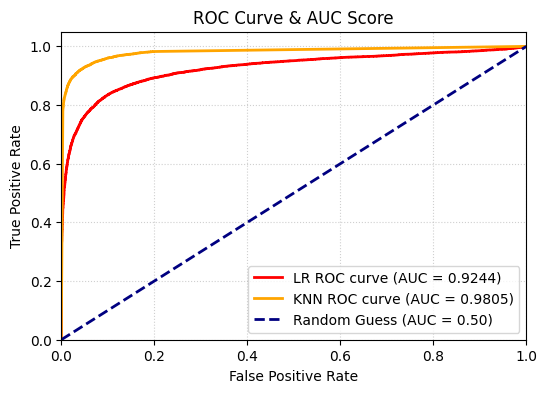

In [69]:
# Evaluation metrics
fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_proba_log)
auc_log = roc_auc_score(y_test, y_proba_log)

fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_proba_knn)
auc_knn = roc_auc_score(y_test,  y_proba_knn)

plt.figure(figsize=(6,4))
plt.plot(fpr_log, tpr_log, color='red', lw=2, label=f'LR ROC curve (AUC = {auc_log:.4f})')
plt.plot(fpr_knn, tpr_knn, color='orange', lw=2, label=f'KNN ROC curve (AUC = {auc_knn:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve & AUC Score')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

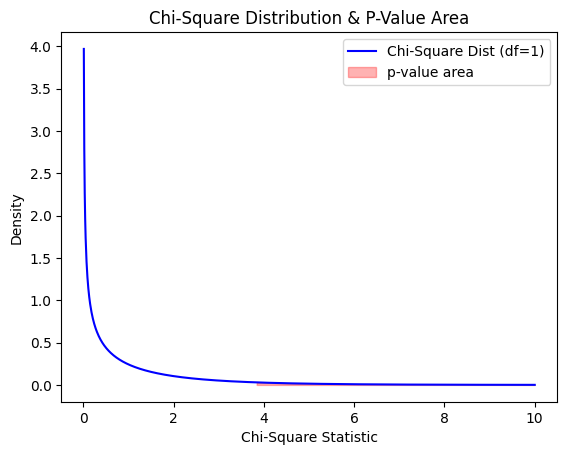

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# 1. إعداد البيانات (درجات الحرية وقيمة كاي المحسوبة)
df_value = 1 # درجات الحرية في مثالنا
chi_stat = 3.84 # مثال لقيمة محسوبة
x = np.linspace(0, 10, 1000)
y = chi2.pdf(x, df_value)

# 2. الرسم
plt.plot(x, y, label=f'Chi-Square Dist (df={df_value})', color='blue')

# 3. تظليل مساحة الـ p-value
x_shade = np.linspace(chi_stat, 10, 100)
plt.fill_between(x_shade, chi2.pdf(x_shade, df_value), color='red', alpha=0.3, label='p-value area')

plt.title('Chi-Square Distribution & P-Value Area')
plt.xlabel('Chi-Square Statistic')
plt.ylabel('Density')
plt.legend()
plt.show()

## Part 5: Final Comparative Analysis
*(Double click this cell to edit)*

**Write your final conclusions here:**
Which model performed best according to your metrics, and why do you think that is?
